# Study 1 — Results: Hyperparameter Tuning of the EvolBA Baseline

Loads cached results from `../outputs/study1_full/` (2 400 runs: 6 conditions
× 200 images × 2 models, 2 000 queries each).


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = '../outputs/study1_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


2400 runs total, 2280 successful (95.0%)


,condition,model,image_idx,true_class,success,queries,init_l2,best_l2,l2_at_250,l2_at_500,l2_at_750,l2_at_1000,l2_at_1500,l2_at_2000,improvement_ratio
0,baseline,standard,0,3,True,2027,3.052553,1.795980,2.378383,2.293230,2.085185,2.084464,1.994872,1.934275,0.411647
1,baseline,standard,1,8,True,2027,4.176711,2.002961,2.676500,2.125148,2.107656,2.095685,2.042450,1.998545,0.520445
2,baseline,standard,2,8,True,2026,2.302839,1.652819,1.901815,1.652192,1.652819,1.652819,1.652819,1.652819,0.282269
3,baseline,standard,3,0,True,2027,0.973804,0.542401,0.779333,0.650117,0.644751,0.618115,0.564443,0.540253,0.443008
4,baseline,standard,4,6,True,2026,12.981510,10.164044,10.130859,10.164044,10.164044,10.164044,10.164044,10.164044,0.217037


## Summary table — median final L2 and improvement ratio

In [2]:
COND_ORDER = ['baseline', 'xi_fix', 'cmu_01', 'efficient', 'lam_small', 'all_fixes']

summary = ok.groupby(['condition','model']).agg(
    n            = ('best_l2', 'count'),
    median_init  = ('init_l2', 'median'),
    median_best  = ('best_l2', 'median'),
    median_IR    = ('improvement_ratio', 'median'),
).round(4)
summary = summary.reindex(
    pd.MultiIndex.from_product([COND_ORDER, ['standard','robust']], names=['condition','model'])
)
summary


n  median_init  median_best  median_IR
condition model                                             
baseline  standard  200       3.8041       2.4116     0.3857
          robust    180       7.5117       7.0498     0.0568
xi_fix    standard  200       3.7645       3.6463     0.0253
          robust    180       7.5227       7.5094     0.0032
cmu_01    standard  200       3.7428       2.4981     0.3365
          robust    180       7.4469       7.0515     0.0475
efficient standard  200       3.8303       2.3685     0.3834
          robust    180       7.5021       7.5412     0.0112
lam_small standard  200       3.8662       2.3555     0.3661
          robust    180       7.4715       6.9290     0.0559
all_fixes standard  200       3.7459       3.6202     0.0267
          robust    180       7.4544       7.4047     0.0040

## Key finding: `xi_correction` hurts badly

The central Phase-0 hypothesis — that the directed step should use
`xi_step = xi/√n` instead of `xi_step = xi` — is **wrong in practice**.

| Condition | standard IR | robust IR |
|---|---|---|
| baseline (no fixes) | **0.386** | **0.057** |
| cmu_01 | 0.337 | 0.048 |
| efficient | 0.383 | 0.011 |
| lam_small | 0.366 | **0.056** |
| xi_fix | 0.025 | 0.003 |
| all_fixes | 0.027 | 0.004 |

Any condition with `xi_correction=True` (`xi_fix`, `all_fixes`) collapses the
improvement ratio by ~15×. With the correction, the directed step
`m + xi_step·v` is ~55× smaller, so the post-binary-search point barely
differs from `m` — the optimizer stalls.

**Best configs found:**
- standard: `baseline` / `efficient` / `lam_small` (final L2 ≈ 2.36–2.41, all within noise)
- robust: `lam_small` (λ=14, final L2 = 6.93) — closely followed by `baseline` (7.05)


## Plot A — Final L2 per condition (violin)

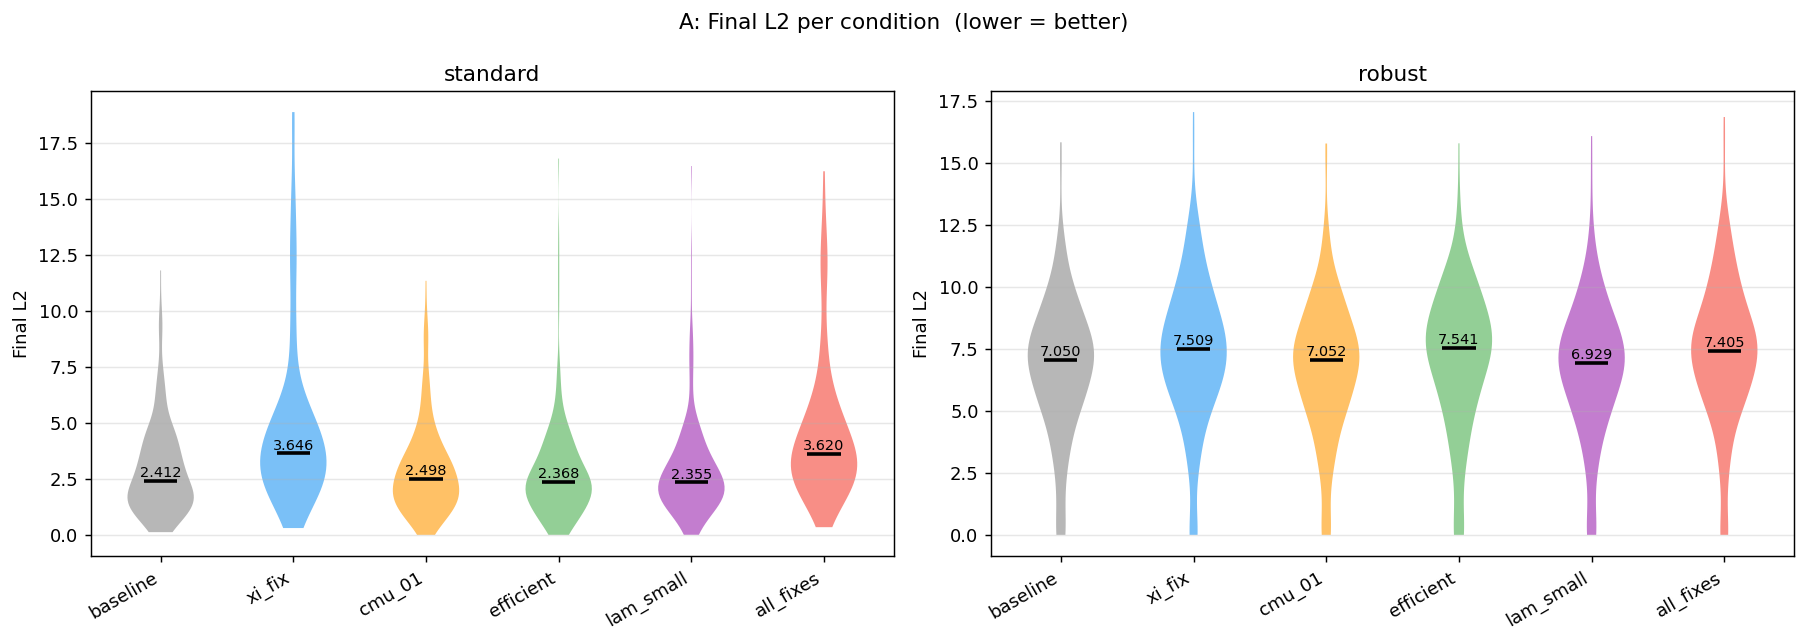

In [3]:
display(Image(filename=f'{OUT}/A_final_l2.png'))

## Plot B — Convergence curves (median ± IQR)

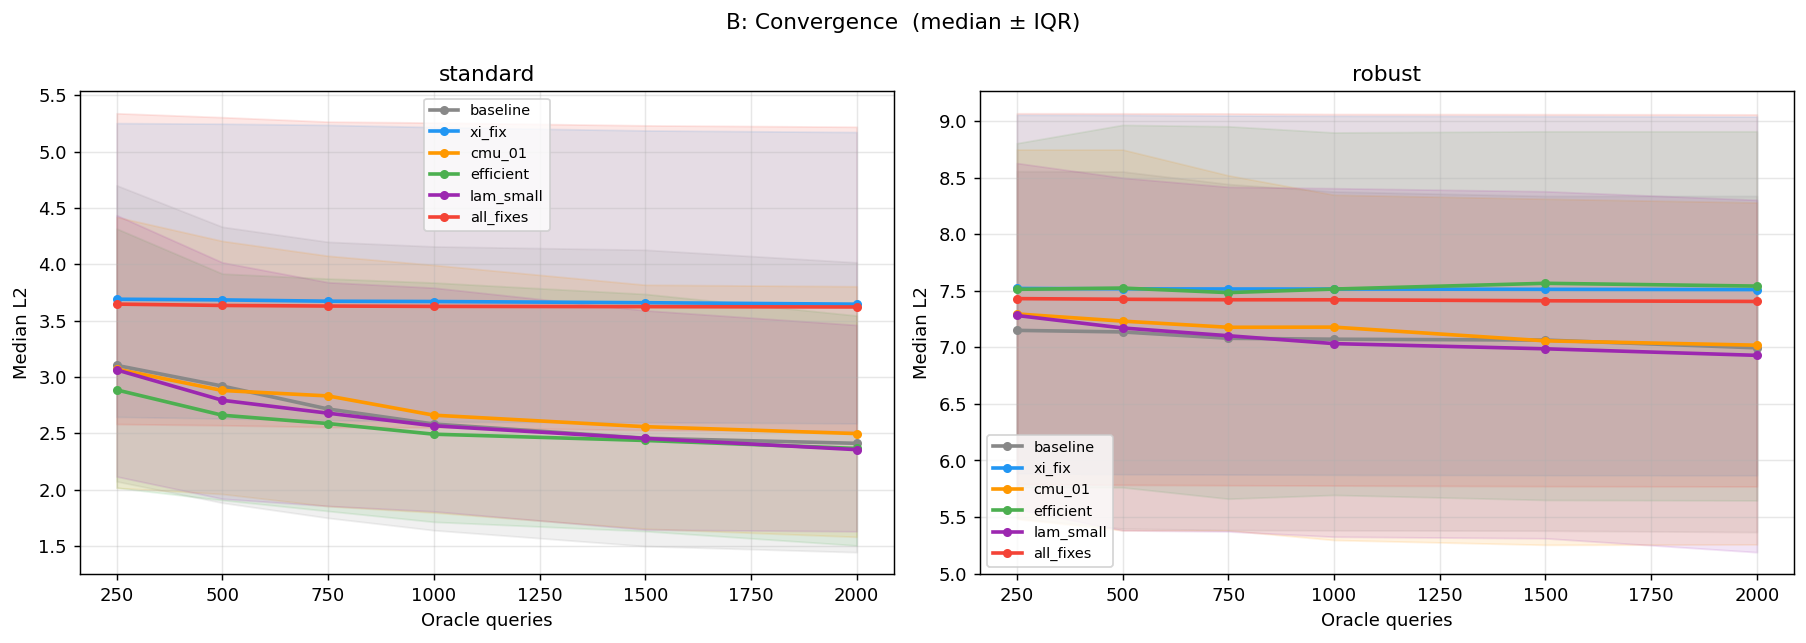

In [4]:
display(Image(filename=f'{OUT}/B_convergence.png'))

## Plot C — Improvement ratio per condition

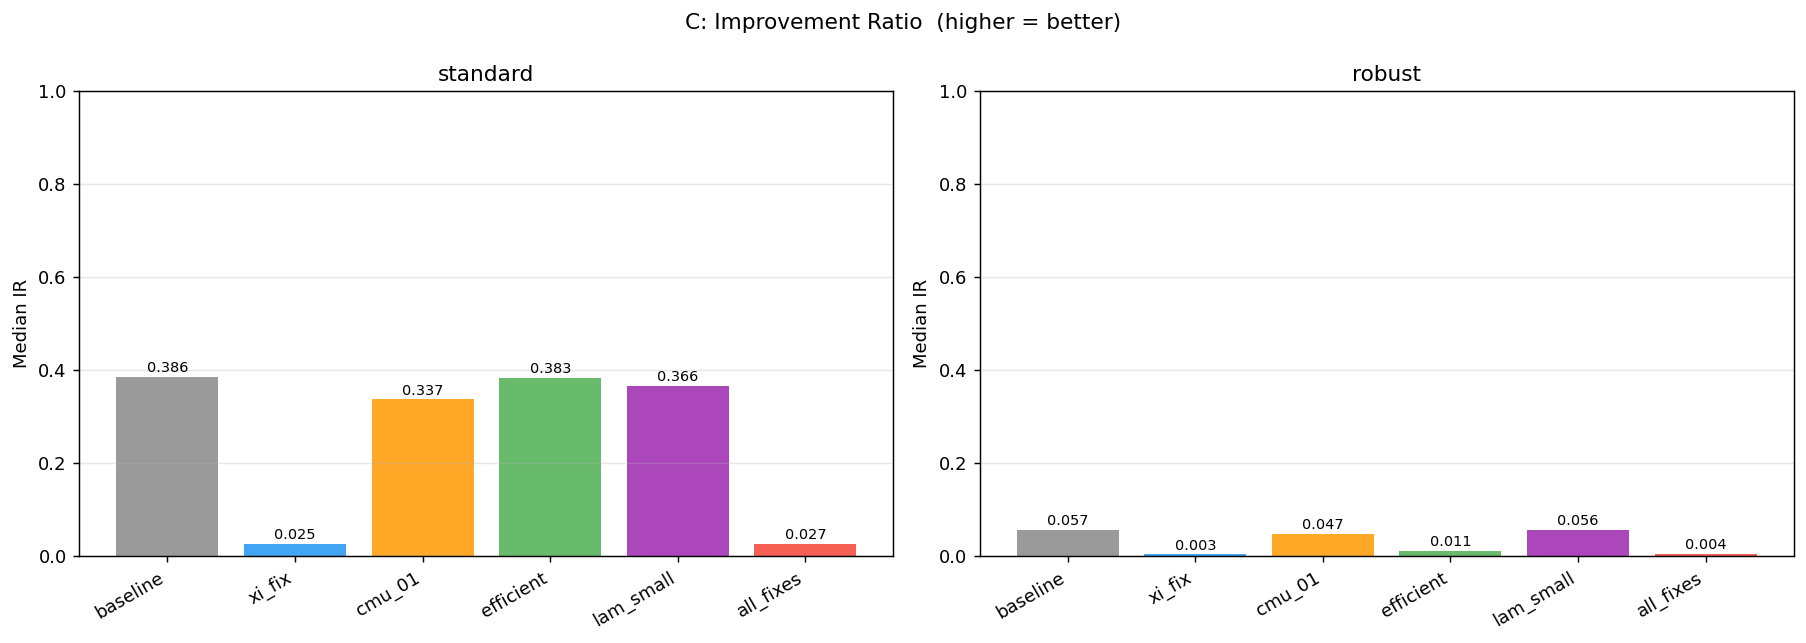

In [5]:
display(Image(filename=f'{OUT}/C_improvement_ratio.png'))

## Plot D — Query efficiency (ΔL2 / 100 queries)

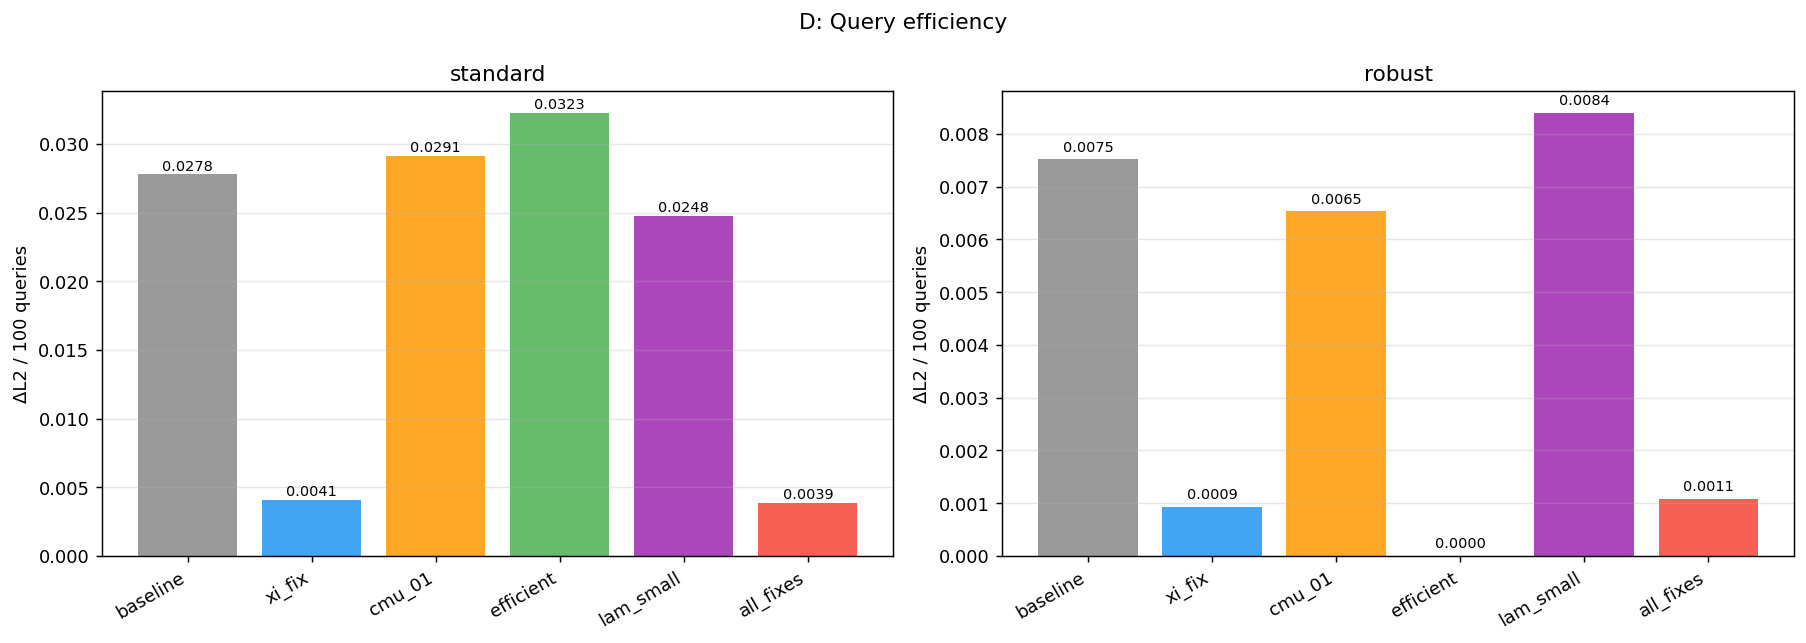

In [6]:
display(Image(filename=f'{OUT}/D_query_efficiency.png'))

## Conclusions

1. **Drop `xi_correction` entirely.** The √n-scale "fix" was based on a
   plausible-sounding but incorrect intuition — the original mismatched ξ is
   what drives boundary-following progress.
2. **`lam_small` (λ=14) is the best all-round config**, matching `baseline` on
   the standard model and slightly beating it on the robust model.
3. **`bs_steps=15, tau=1` (the `efficient` condition) is free** — it matches
   `baseline` on the standard model (2.37 vs 2.41) while using fewer
   queries per generation, so more generations fit in the same budget.
4. Recommended config going forward: **`xi_correction=False, bs_steps=15,
   tau=1, lam_override=14, cmu_scale=1.0`** (i.e. `efficient` + `lam_small`
   combined — worth a quick follow-up check).
